In [1]:
import numpy as np
from numpy import zeros, argmax
from scipy.stats import beta

In [2]:
class EpsilonGreedy:
    def __init__(self, arms=None, epsilon=0.01):
        self.arms = arms if arms else 3
        self.epsilon = epsilon
        self.est_payoffs = np.zeros(self.arms)
        self.counts = np.zeros(self.arms)

    def policy_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.arms)  # Explore
        else:
            return np.argmax(self.est_payoffs)  # Exploit

    def policy_update(self, action, reward):
        self.counts[action] += 1
        alpha = 1.0 / self.counts[action]
        self.est_payoffs[action] += alpha * (reward - self.est_payoffs[action])

In [3]:
class ThompsonSampling:
    def __init__(self, arms=None):
        self.arms = arms if arms else 3
        self.est_payoffs = zeros(self.arms)
        self.K = zeros(self.arms)
        self.wins = zeros(self.arms)
        
    def policy_action(self):
        return argmax(beta(1 + self.wins, 1 + self.K - self.wins).rvs())
    
    def policy_update(self, action, reward):
        score = 1 if reward > 1 else 0
        self.K[action] += 1
        self.wins[action] += score
        alpha = 1.0 / self.K[action]
        self.est_payoffs[action] += alpha * (reward - self.est_payoffs[action])

In [4]:
class CentipedeGame:
    def __init__(self, player1, player2, rounds, payoff_matrix=None):
        self.player1 = player1
        self.player2 = player2
        self.rounds = rounds
        self.history = []
        self.payoff_matrix = payoff_matrix if payoff_matrix else [[6, 3, 1], [7, 4, 1], [5, 5, 2]]
        # Print the payoff matrix for debugging
        # print(f"Initialized CentipedeGame with payoff matrix:\n{self.payoff_matrix}")

    def play_round(self, round_number):
        r_act = self.player1.policy_action()
        c_act = self.player2.policy_action()
        # print(f"Player 1 action: {r_act}, Player 2 action: {c_act}")  # Debugging print
        if r_act >= len(self.payoff_matrix) or c_act >= len(self.payoff_matrix):
            raise IndexError(f"Action indices out of bounds: r_act={r_act}, c_act={c_act}")
        r_rd, c_rd = self.expected_payoff(r_act, c_act)
        self.player1.policy_update(r_act, r_rd)
        self.player2.policy_update(c_act, c_rd)
        self.history.append((round_number + 1, r_act, c_act, r_rd, c_rd))  # Include both r_rd and c_rd with the round number
    
    def expected_payoff(self, r_act, c_act):
        return self.payoff_matrix[r_act][c_act], self.payoff_matrix[c_act][r_act]
    
    def run_game(self):
        for round_number in range(self.rounds):
            self.play_round(round_number)
        return self.history

In [5]:
import ray
@ray.remote
class EpsilonGreedySimulation:
    def __init__(self, game_params):
        self.game_params = game_params

    def run_simulation(self):
        try:
            # Get the number of arms from the payoff matrix
            num_arms = len(self.game_params['payoff_matrix'])
            player1 = EpsilonGreedy(arms=num_arms)
            player2 = EpsilonGreedy(arms=num_arms)
            game = CentipedeGame(player1, player2, self.game_params['rounds'], self.game_params.get('payoff_matrix'))
            return game.run_game()
        except Exception as e:
            print(f"Error during simulation: {e}")
            return None

@ray.remote
class BayesianSimulation:
    def __init__(self, game_params):
        self.game_params = game_params

    def run_simulation(self):
        try:
            # Get the number of arms from the payoff matrix
            num_arms = len(self.game_params['payoff_matrix'])
            player1 = ThompsonSampling(arms=num_arms)
            player2 = ThompsonSampling(arms=num_arms)
            game = CentipedeGame(player1, player2, self.game_params['rounds'], self.game_params.get('payoff_matrix'))
            return game.run_game()
        except Exception as e:
            print(f"Error during simulation: {e}")
            return None

In [6]:
def create_centipede_game(N):
    """
    Create an N x N Centipede Game payoff matrix based on the complete rules.
    
    Parameters:
    N (int): Number of stages in the Centipede Game.
    
    Returns:
    list: A nested list representing the row's payoffs.
    """
    payoff_matrix = []

    for s1 in range(N):
        row = []
        for s2 in range(N):
            if s1 < s2:
                payoff_s1 = 2 * s1 + 5
            elif s1 == s2:
                payoff_s1 = 2 * s1 + 2
            else:
                payoff_s1 = 2 * s2 + 1
            row.append(payoff_s1)
        payoff_matrix.append(row)

    return payoff_matrix

def invert_matrix(matrix):
    """
    Invert the matrix by switching rows and mirror-flipping the values in each row.
    
    Parameters:
    matrix (list of lists): The original matrix.
    
    Returns:
    list: The inverted matrix.
    """
    # Switch the rows: first with last, second with penultimate, etc.
    inverted_matrix = matrix[::-1]
    
    # Mirror-flip the values in each row
    for i in range(len(inverted_matrix)):
        inverted_matrix[i] = inverted_matrix[i][::-1]
    
    return inverted_matrix

In [7]:
def run_epsilon_simulations(num_simulations, game_params):
    simulation_actors = [EpsilonGreedySimulation.remote(game_params) for _ in range(num_simulations)]
    results = ray.get([actor.run_simulation.remote() for actor in simulation_actors])
    return results

def run_bayesian_simulations(num_simulations, game_params):
    simulation_actors = [BayesianSimulation.remote(game_params) for _ in range(num_simulations)]
    results = ray.get([actor.run_simulation.remote() for actor in simulation_actors])
    return results

In [8]:
import pandas as pd

class DataCollection:
    def __init__(self):
        self.data = []

    def collect_data(self, game_data):
        for game in game_data:
            if game is not None:
                for round_data in game:
                    self.data.append(round_data)

    def aggregate_data(self):
        df = pd.DataFrame(self.data, columns=['round', 'r_act', 'c_act', 'r_rd', 'c_rd'])
        aggregated_data = df.groupby(['round']).mean().reset_index()
        return aggregated_data

    def save_data(self, filename):
        df = pd.DataFrame(self.data, columns=['round', 'r_act', 'c_act', 'r_rd', 'c_rd'])
        df.to_csv(filename, index=False)

In [9]:
# Define the number of simulations and game parameters
num_simulations = 1000

# Example for 6x6 Centipede Game
N = 10
payoff_matrix = create_centipede_game(N)
payoff_matrix = invert_matrix(payoff_matrix)

game_params = {
    'rounds': 5000,  # Example value
    'payoff_matrix': payoff_matrix  # Custom payoff matrix
}

# Start timing
import time
start_time = time.time()
ray.init()

# Run all simulations
results = run_bayesian_simulations(num_simulations, game_params)

# Collect and aggregate data
data_collector = DataCollection()
data_collector.collect_data(results)
aggregated_data = data_collector.aggregate_data()
data_collector.save_data('centipede_bayesian_results.csv')

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
elapsed_minutes = elapsed_time / 60
print(f"Total execution time: {elapsed_minutes} minutes")

2024-06-06 13:51:05,854	INFO worker.py:1740 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


(raylet) WARNING: 64 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 112 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds). [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(raylet) WARNING: 136 PYTHON worker processes have been started on no

(raylet) WARNING: 520 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 530 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 542 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 fo

(raylet) WARNING: 936 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds). [repeated 2x across cluster]
(raylet) WARNING: 948 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 960 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/r

(raylet) WARNING: 1272 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 1286 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 1296 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644

(raylet) WARNING: 1610 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 1620 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 1634 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644

(raylet) WARNING: 1908 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 1921 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 1934 PYTHON worker processes have been started on node: c9304f968c13451ca2f5e384a6caea3b63d7c78e4b90c414e129383a with address: 127.0.0.1. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644

In [10]:
# Load the CSV file
df = pd.read_csv('centipede_bayesian_results.csv')

# Check the number of rows
num_rows = df.shape[0]
print(f"Total number of rows: {num_rows}")

# Check the DataFrame columns
print(df.columns)

Total number of rows: 5000000
Index(['round', 'r_act', 'c_act', 'r_rd', 'c_rd'], dtype='object')


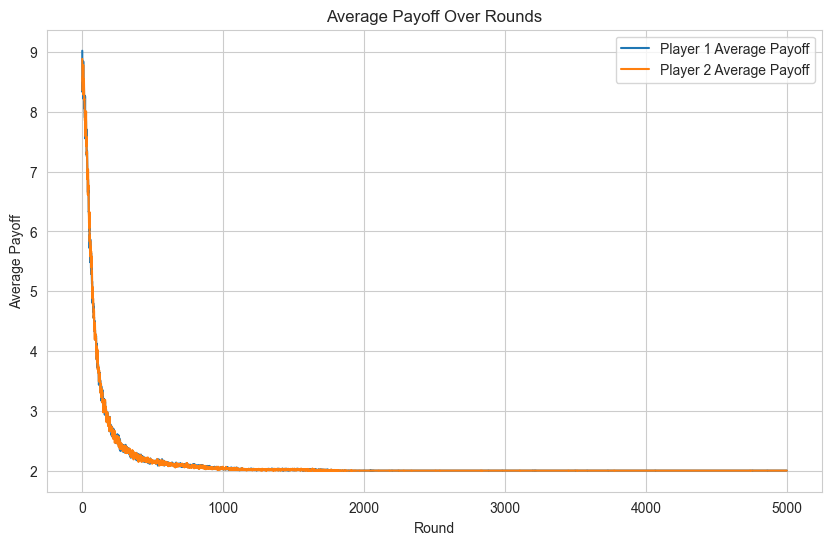

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Aggregate data by round to calculate the average payoffs for each round
aggregated_data = df.groupby('round')[['r_rd', 'c_rd']].mean().reset_index()

# Plot the average payoffs over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=aggregated_data, x='round', y='r_rd', label='Player 1 Average Payoff')
sns.lineplot(data=aggregated_data, x='round', y='c_rd', label='Player 2 Average Payoff')
plt.title('Average Payoff Over Rounds')
plt.xlabel('Round')
plt.ylabel('Average Payoff')
plt.legend()
plt.show()

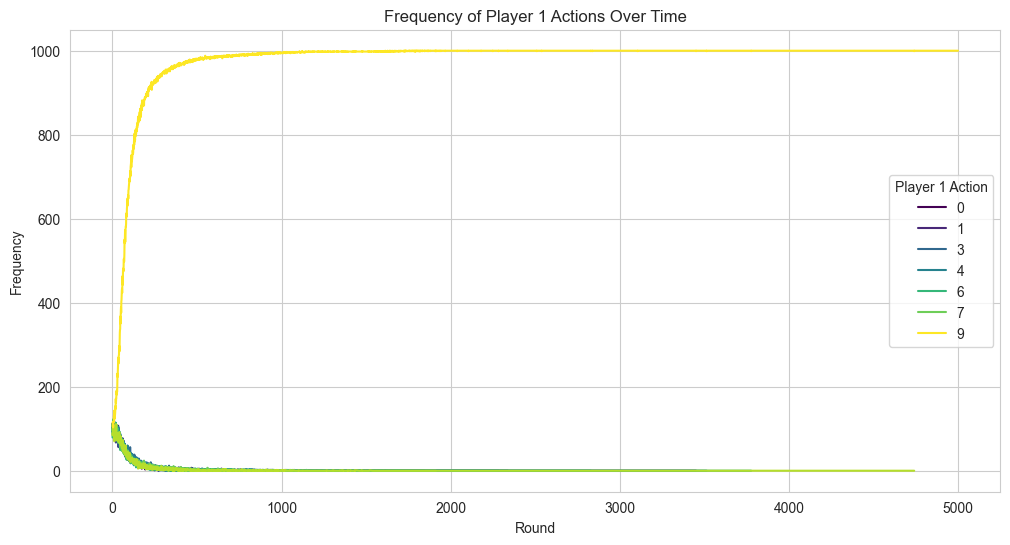

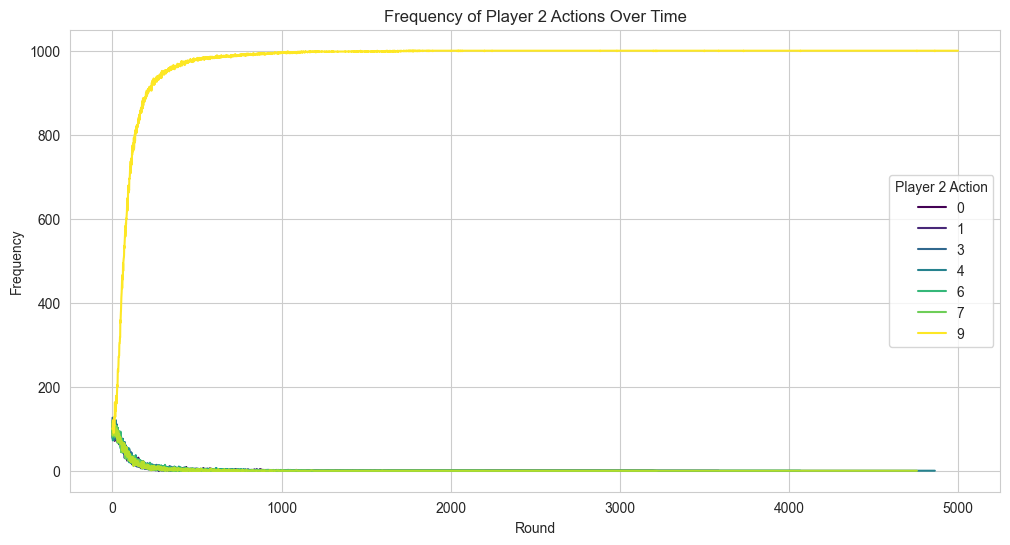

In [12]:
# Create a new DataFrame for counting action frequencies over rounds
action_freq_over_time = df.groupby(['round', 'r_act', 'c_act']).size().reset_index(name='count')

# Separate data for Player 1 and Player 2 actions
player1_actions = df.groupby(['round', 'r_act']).size().reset_index(name='count')
player2_actions = df.groupby(['round', 'c_act']).size().reset_index(name='count')

# Plot Player 1 actions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=player1_actions, x='round', y='count', hue='r_act', palette='viridis')
plt.title('Frequency of Player 1 Actions Over Time')
plt.xlabel('Round')
plt.ylabel('Frequency')
plt.legend(title='Player 1 Action')
plt.show()

# Plot Player 2 actions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=player2_actions, x='round', y='count', hue='c_act', palette='viridis')
plt.title('Frequency of Player 2 Actions Over Time')
plt.xlabel('Round')
plt.ylabel('Frequency')
plt.legend(title='Player 2 Action')
plt.show()

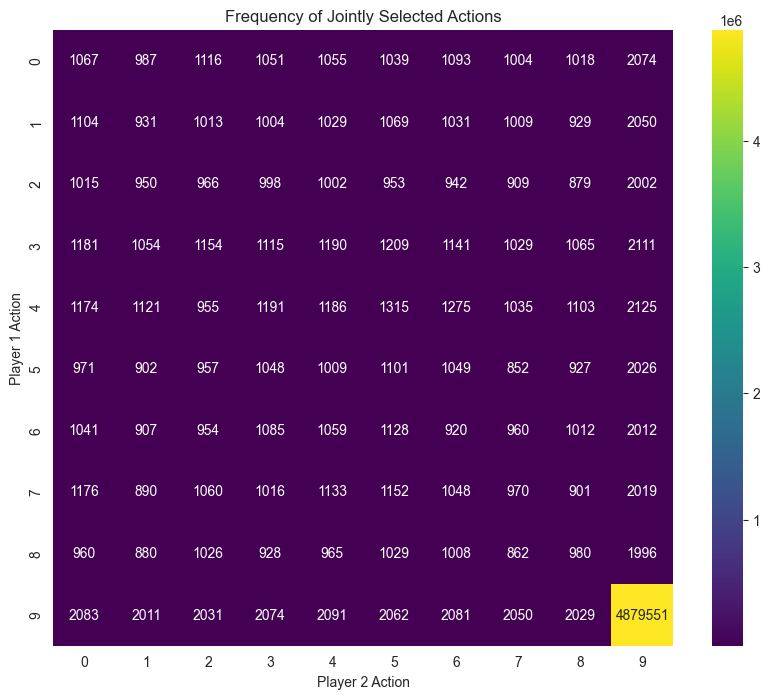

In [13]:
# Aggregate data to count the occurrences of each action combination
action_counts = df.groupby(['r_act', 'c_act']).size().reset_index(name='count')

# Pivot the data to create a matrix for the heatmap
heatmap_data = action_counts.pivot(index='r_act', columns='c_act', values='count')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='d')
plt.title('Frequency of Jointly Selected Actions')
plt.xlabel('Player 2 Action')
plt.ylabel('Player 1 Action')
plt.show()